In [3]:
import pandas as pd
from tsfresh import extract_features

# Load your CSV
df = pd.read_csv("./data/data.csv")

# Rename columns if needed to match tsfresh expectation
df = df.rename(columns={"hash_id": "id", "epoch_no": "time", "amount": "value"})
# Ensure data is sorted by id and time
df = df.sort_values(by=["id", "time"])

# This computes many statistical features per hash_id
features = extract_features(df, column_id="id", column_sort="time")


/Users/Joel/Documents/GitHub/ada_drep/.venv/lib/python3.12/site-packages/tsfresh/__init__.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Feature Extraction:   0%|          | 0/30 [00:00<?, ?it/s]/Users/Joel/Documents/GitHub/ada_drep/.venv/lib/python3.12/site-packages/tsfresh/__init__.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/Users/Joel/Documents/GitHub/ada_drep/.venv/lib/python3.12/site-packages/tsfresh/__init__.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_

In [4]:
import pandas as pd

# Ensure sorted
df = df.sort_values(by=["id", "time"])

# Compute percentage change per id
df["value_pct_change"] = df.groupby("id")["value"].pct_change()

# Remove NaN rows from pct_change
df = df.dropna(subset=["value_pct_change"])

# Pivot so each id is a column, indexed by time
df_pivot = df.pivot(index="time", columns="id", values="value_pct_change")

# Compute correlation matrix between ids based on pct_change
corr_matrix = df_pivot.corr()

# Optional: save or inspect
print(corr_matrix)


id        1         2         3         5         6         8         9       \
id                                                                             
1       1.000000  0.016065 -0.041851       NaN  0.388512  0.059495 -0.003215   
2       0.016065  1.000000  0.372509  0.832384  0.124589 -0.085054 -0.021804   
3      -0.041851  0.372509  1.000000 -0.386870 -0.021519 -0.016743  0.007617   
5            NaN  0.832384 -0.386870  1.000000  0.568524 -0.222385       NaN   
6       0.388512  0.124589 -0.021519  0.568524  1.000000  0.357450  0.035259   
...          ...       ...       ...       ...       ...       ...       ...   
115323 -1.000000 -1.000000       NaN       NaN -1.000000 -1.000000  1.000000   
115456  1.000000  1.000000       NaN       NaN  1.000000  1.000000 -1.000000   
115827       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
116209 -1.000000 -1.000000       NaN       NaN -1.000000 -1.000000  1.000000   
120241       NaN       NaN       NaN    

In [5]:
from tsfresh.utilities.dataframe_functions import impute
from sklearn.preprocessing import StandardScaler

# Handle NaN/inf from tsfresh
features_imputed = impute(features)

# Optional: normalize
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_imputed)


/Users/Joel/Documents/GitHub/ada_drep/.venv/lib/python3.12/site-packages/tsfresh/utilities/dataframe_functions.py:198: RuntimeWarning: The columns ['value__fft_coefficient__attr_"real"__coeff_34'
 'value__fft_coefficient__attr_"real"__coeff_35'
 'value__fft_coefficient__attr_"real"__coeff_36'
 'value__fft_coefficient__attr_"real"__coeff_37'
 'value__fft_coefficient__attr_"real"__coeff_38'
 'value__fft_coefficient__attr_"real"__coeff_39'
 'value__fft_coefficient__attr_"real"__coeff_40'
 'value__fft_coefficient__attr_"real"__coeff_41'
 'value__fft_coefficient__attr_"real"__coeff_42'
 'value__fft_coefficient__attr_"real"__coeff_43'
 'value__fft_coefficient__attr_"real"__coeff_44'
 'value__fft_coefficient__attr_"real"__coeff_45'
 'value__fft_coefficient__attr_"real"__coeff_46'
 'value__fft_coefficient__attr_"real"__coeff_47'
 'value__fft_coefficient__attr_"real"__coeff_48'
 'value__fft_coefficient__attr_"real"__coeff_49'
 'value__fft_coefficient__attr_"real"__coeff_50'
 'value__fft_coeffic

In [6]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

features_clean = features_imputed.fillna(0)
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_clean)

k = 4  # Number of clusters
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(features_scaled)

# Add cluster labels to DataFrame
features_clean['cluster'] = labels
print(features_clean[['cluster']].head())


   cluster
1        1
2        1
3        1
5        3
6        1


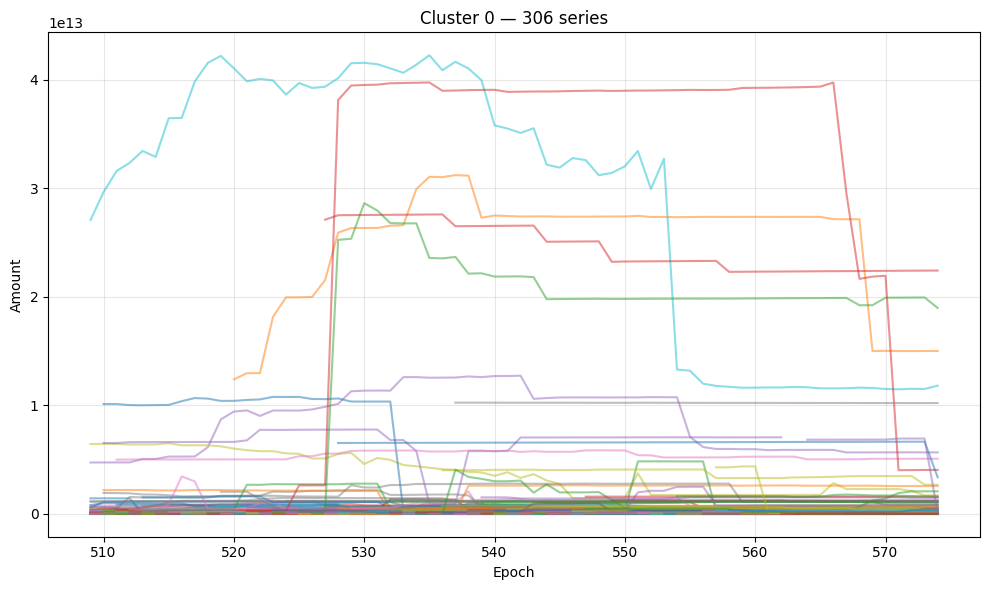

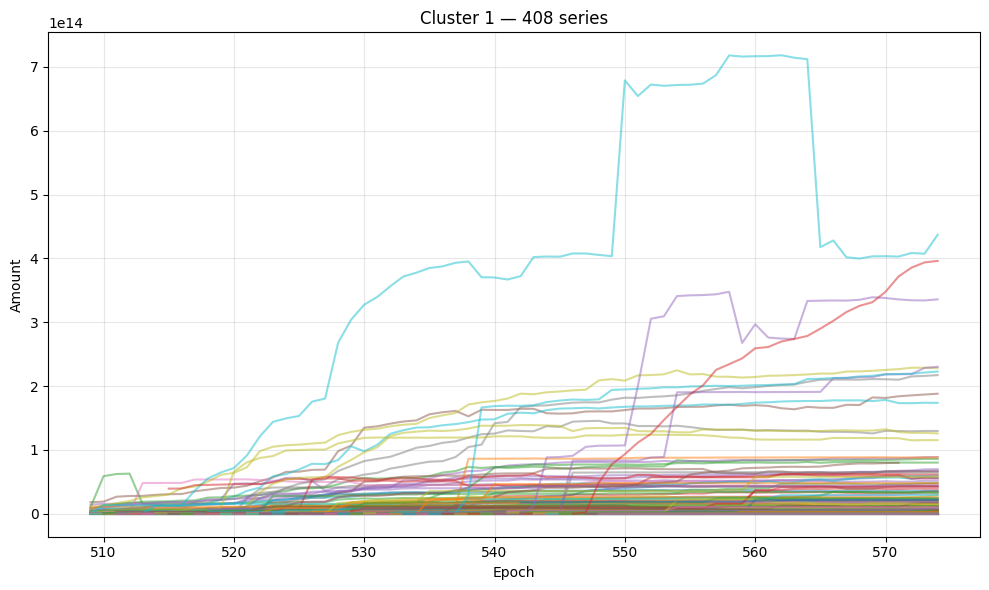

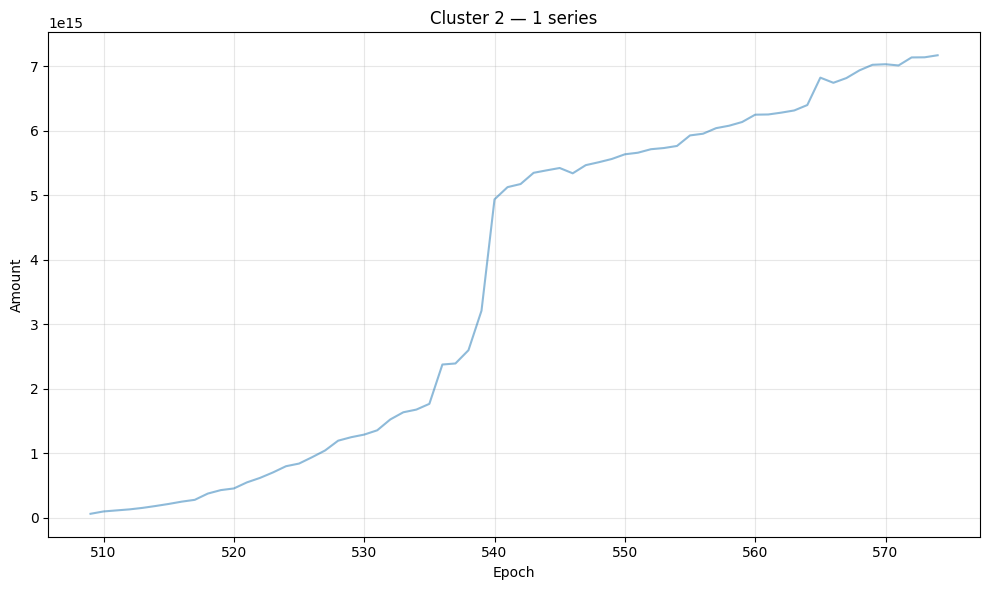

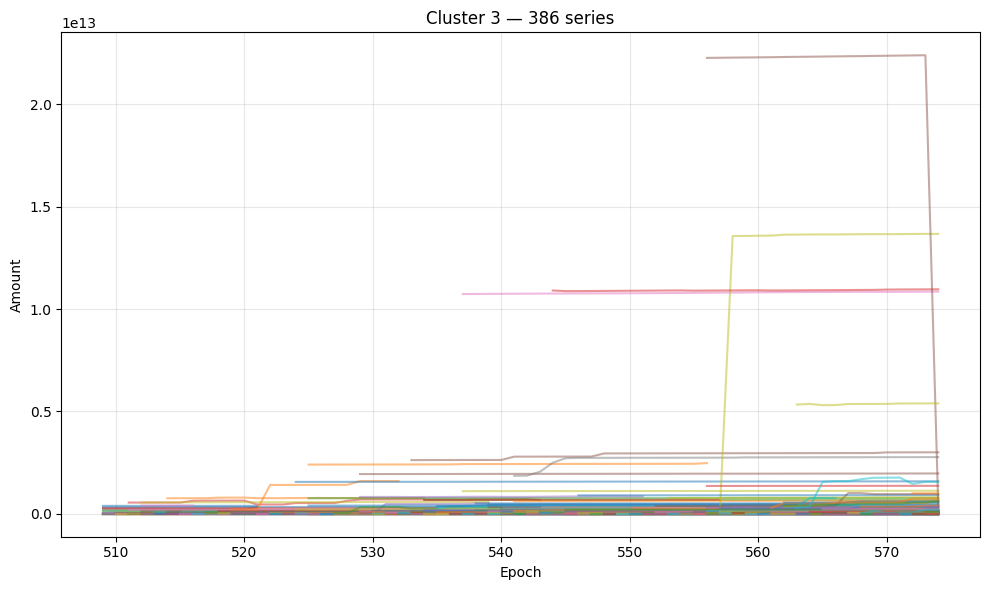

In [7]:
import matplotlib.pyplot as plt

# Merge the cluster labels back into the original df
df_with_clusters = df.merge(
    features_clean[['cluster']],
    left_on='id',
    right_index=True
)

# Plot each cluster separately
for cluster_id in sorted(df_with_clusters['cluster'].unique()):
    cluster_data = df_with_clusters[df_with_clusters['cluster'] == cluster_id]
    
    plt.figure(figsize=(10, 6))
    
    for series_id in cluster_data['id'].unique():
        series_data = cluster_data[cluster_data['id'] == series_id]
        plt.plot(series_data['time'], series_data['value'], alpha=0.5)
    
    plt.title(f"Cluster {cluster_id} — {len(cluster_data['id'].unique())} series")
    plt.xlabel("Epoch")
    plt.ylabel("Amount")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


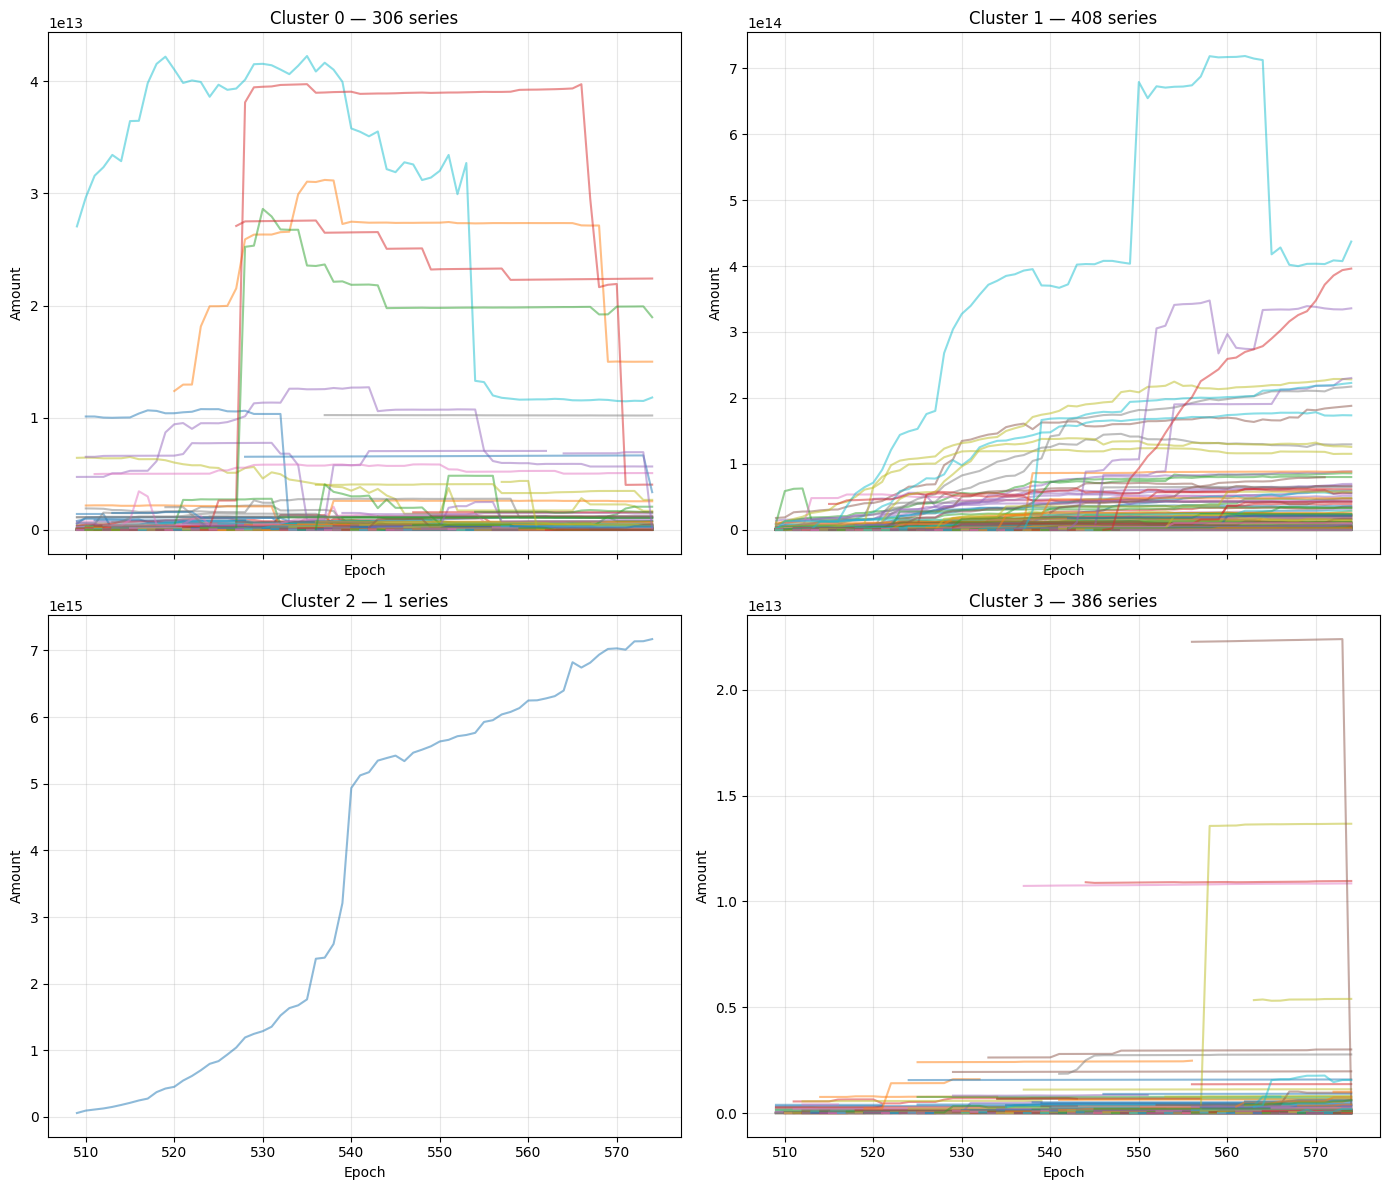

In [8]:
import matplotlib.pyplot as plt
import math

# Merge cluster labels
df_with_clusters = df.merge(
    features_clean[['cluster']],
    left_on='id',
    right_index=True
)

clusters = sorted(df_with_clusters['cluster'].unique())
n_clusters = len(clusters)

# Set up rows & cols for subplots (e.g., 2x2 for 4 clusters)
rows = math.ceil(n_clusters / 2)
cols = 2

fig, axes = plt.subplots(rows, cols, figsize=(14, 6 * rows), sharex=True)

# Flatten axes for easy indexing
axes = axes.flatten()

for i, cluster_id in enumerate(clusters):
    ax = axes[i]
    cluster_data = df_with_clusters[df_with_clusters['cluster'] == cluster_id]
    
    for series_id in cluster_data['id'].unique():
        series_data = cluster_data[cluster_data['id'] == series_id]
        ax.plot(series_data['time'], series_data['value'], alpha=0.5)
    
    ax.set_title(f"Cluster {cluster_id} — {len(cluster_data['id'].unique())} series")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Amount")
    ax.grid(True, alpha=0.3)

# Remove unused subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


PCA component names: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10']


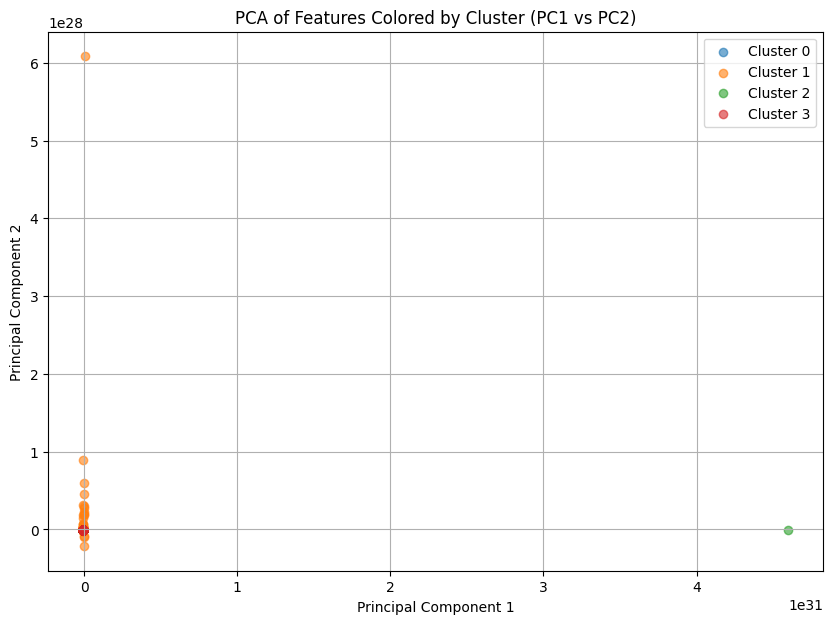

In [10]:
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt

# Assuming features_clean is your features DataFrame (without 'cluster' column)
features_only = features_clean.drop(columns=['cluster'], errors='ignore')

# Fit PCA to scaled features
pca = PCA(n_components=10)
pca_result = pca.fit_transform(features_only)

# Create a DataFrame with all 10 PCA components
pc_columns = [f'PC{i+1}' for i in range(pca_result.shape[1])]
pca_df = pd.DataFrame(pca_result, columns=pc_columns, index=features_only.index)

# Add cluster labels
pca_df['cluster'] = features_clean['cluster']

# Print PCA component names
print("PCA component names:", pc_columns)

# Optional: plot only the first 2 PCs colored by cluster
plt.figure(figsize=(10, 7))
for cluster_id in sorted(pca_df['cluster'].unique()):
    subset = pca_df[pca_df['cluster'] == cluster_id]
    plt.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {cluster_id}', alpha=0.6)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Features Colored by Cluster (PC1 vs PC2)')
plt.legend()
plt.grid(True)
plt.show()


In [11]:
# pca.components_ gives the weights for each PC
loadings = pd.DataFrame(pca.components_, columns=features_only.columns, index=pc_columns)
print(loadings)


      value__variance_larger_than_standard_deviation  \
PC1                                    -0.000000e+00   
PC2                                     4.128777e-17   
PC3                                    -9.879793e-18   
PC4                                    -2.559581e-17   
PC5                                    -1.150459e-17   
PC6                                     1.418704e-18   
PC7                                    -3.579843e-18   
PC8                                    -1.458900e-18   
PC9                                     1.706120e-17   
PC10                                    6.846784e-18   

      value__has_duplicate_max  value__has_duplicate_min  \
PC1              -8.487380e-34             -1.908328e-33   
PC2              -1.292963e-25             -1.559482e-30   
PC3               1.183949e-16             -6.030341e-25   
PC4              -6.422884e-17              3.936376e-18   
PC5              -1.578457e-17             -8.941091e-17   
PC6              -1.336

In [14]:
df.columns

Index(['id', 'value', 'time', 'value_pct_change'], dtype='object')

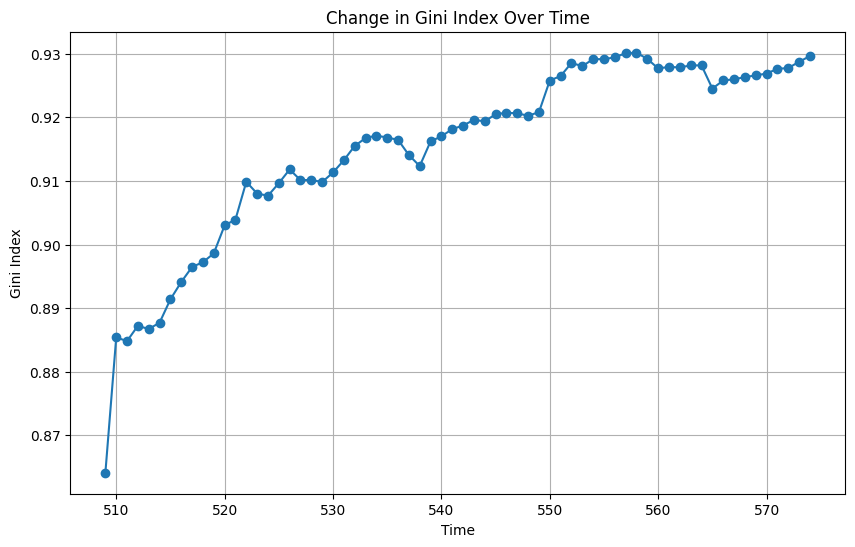

In [20]:
import numpy as np


# Example: df is your DataFrame with ['id', 'value', 'time', 'value_pct_change']

def gini(array):
    """Compute Gini index of a numpy array."""
    # All values must be non-negative
    array = np.array(array, dtype=np.float64)
    if np.amin(array) < 0:
        array -= np.amin(array)  
    array += 1e-10  # avoid division by zero

    array = np.sort(array)
    n = array.shape[0]
    cumulative = np.cumsum(array)
    gini_index = (n + 1 - 2 * np.sum(cumulative) / cumulative[-1]) / n
    return gini_index

df_no_abstain = df[df["id"]!=14]
# Group by time and compute Gini index of 'value'
gini_by_time = df_no_abstain.groupby("time")["value"].apply(gini).reset_index(name="gini_index")

# Convert epoch to datetime for nicer x-axis
# Plot
plt.figure(figsize=(10,6))
plt.plot(gini_by_time["time"], gini_by_time["gini_index"], marker="o")
plt.xlabel("Time")
plt.ylabel("Gini Index")
plt.title("Change in Gini Index Over Time")
plt.grid(True)
plt.show()


In [18]:
# Find the last time (max epoch)
last_time = df["time"].max()

# Filter rows at that time
last_time_df = df[df["time"] == last_time]

# Find the id with the largest value
max_id_row = last_time_df.loc[last_time_df["value"].idxmax()]

print("ID with largest value at last time:")
print(max_id_row)


ID with largest value at last time:
id                  1.400000e+01
value               7.170518e+15
time                5.740000e+02
value_pct_change    4.441943e-03
Name: 45689, dtype: float64
